# 04 — Statistical Analysis

Analysis of trip patterns, correlations, hypothesis testing, and revenue drivers.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import chi2_contingency

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.4f}".format)

## Project Paths

In [2]:
current_path = Path.cwd()

if current_path.name == "notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

processed_data_dir = project_root / "data" / "processed"
reports_dir = project_root / "reports"
figures_dir = reports_dir / "figures"

processed_data_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

cleaned_trip_data_path = processed_data_dir / "cleaned_yellow_taxi_jan_2024.parquet"

print(f"Project root: {project_root}")
print(f"Cleaned dataset path exists: {cleaned_trip_data_path.exists()}")

Project root: /Users/ayushkumarsingh/Desktop/PROJECTS/Subject_assignments/NYCTaxiTripAnalytics
Cleaned dataset path exists: True


## Load Cleaned Dataset

In [3]:
taxi_trips = pd.read_parquet(cleaned_trip_data_path)

print(f"Cleaned taxi trips shape: {taxi_trips.shape[0]:,} rows and {taxi_trips.shape[1]:,} columns")
taxi_trips.head()

Cleaned taxi trips shape: 2,868,035 rows and 47 columns


,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,rate_code_id,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration_minutes,passenger_count_clean,passenger_count_group,vendor_name,rate_code_label,payment_type_label,pickup_date,pickup_year,pickup_month,pickup_day,pickup_hour,pickup_day_name,pickup_day_of_week,is_weekend,revenue_per_mile,fare_per_minute,tip_percentage,distance_bucket,duration_bucket,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone,is_high_value_trip,is_long_distance_trip,is_long_duration_trip
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0000,1.7200,1.0000,N,186,79,2,17.7000,1.0000,0.5000,0.0000,0.0000,1.0000,22.7000,2.5000,0.0000,19.8000,1,Solo,VeriFone Inc.,Standard rate,Cash,2024-01-01,2024,1,1,0,Monday,0,False,13.1977,0.8939,0.0000,1-3 miles,10-20 min,Manhattan,Penn Station/Madison Sq West,Yellow Zone,Manhattan,East Village,Yellow Zone,False,False,False
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0000,1.8000,1.0000,N,140,236,1,10.0000,3.5000,0.5000,3.7500,0.0000,1.0000,18.7500,2.5000,0.0000,6.6000,1,Solo,Creative Mobile Technologies,Standard rate,Credit card,2024-01-01,2024,1,1,0,Monday,0,False,10.4167,1.5152,37.5000,1-3 miles,5-10 min,Manhattan,Lenox Hill East,Yellow Zone,Manhattan,Upper East Side North,Yellow Zone,False,False,False
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0000,4.7000,1.0000,N,236,79,1,23.3000,3.5000,0.5000,3.0000,0.0000,1.0000,31.3000,2.5000,0.0000,17.9167,1,Solo,Creative Mobile Technologies,Standard rate,Credit card,2024-01-01,2024,1,1,0,Monday,0,False,6.6596,1.3005,12.8755,3-5 miles,10-20 min,Manhattan,Upper East Side North,Yellow Zone,Manhattan,East Village,Yellow Zone,False,False,False
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0000,1.4000,1.0000,N,79,211,1,10.0000,3.5000,0.5000,2.0000,0.0000,1.0000,17.0000,2.5000,0.0000,8.3000,1,Solo,Creative Mobile Technologies,Standard rate,Credit card,2024-01-01,2024,1,1,0,Monday,0,False,12.1429,1.2048,20.0000,1-3 miles,5-10 min,Manhattan,East Village,Yellow Zone,Manhattan,SoHo,Yellow Zone,False,False,False
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0000,0.8000,1.0000,N,211,148,1,7.9000,3.5000,0.5000,3.2000,0.0000,1.0000,16.1000,2.5000,0.0000,6.1000,1,Solo,Creative Mobile Technologies,Standard rate,Credit card,2024-01-01,2024,1,1,0,Monday,0,False,20.1250,1.2951,40.5063,0-1 miles,5-10 min,Manhattan,SoHo,Yellow Zone,Manhattan,Lower East Side,Yellow Zone,False,False,False


## Prepare Statistical Analysis Dataset

In [4]:
analysis_columns = [
    "pickup_datetime",
    "pickup_hour",
    "pickup_day_name",
    "is_weekend",
    "trip_distance",
    "trip_duration_minutes",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "revenue_per_mile",
    "fare_per_minute",
    "tip_percentage",
    "passenger_count_clean",
    "payment_type_label",
    "pickup_borough",
    "dropoff_borough",
    "rate_code_label",
    "distance_bucket",
    "duration_bucket",
]

statistical_dataset = taxi_trips[analysis_columns].copy()

numeric_columns_for_cleaning = [
    "trip_distance",
    "trip_duration_minutes",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "revenue_per_mile",
    "fare_per_minute",
    "tip_percentage",
]

statistical_dataset[numeric_columns_for_cleaning] = statistical_dataset[numeric_columns_for_cleaning].replace(
    [np.inf, -np.inf],
    np.nan
)

statistical_dataset = statistical_dataset.dropna(subset=[
    "trip_distance",
    "trip_duration_minutes",
    "fare_amount",
    "total_amount",
    "payment_type_label",
    "pickup_borough",
    "distance_bucket",
])

print(f"Statistical dataset shape: {statistical_dataset.shape[0]:,} rows and {statistical_dataset.shape[1]:,} columns")

Statistical dataset shape: 2,868,035 rows and 19 columns


## Helper Functions

In [5]:
def interpret_p_value(p_value: float, alpha: float = 0.05) -> str:
    if p_value < alpha:
        return "Statistically significant"
    return "Not statistically significant"


def cohen_d(group_one: pd.Series, group_two: pd.Series) -> float:
    group_one = group_one.dropna()
    group_two = group_two.dropna()

    sample_size_one = len(group_one)
    sample_size_two = len(group_two)

    variance_one = group_one.var(ddof=1)
    variance_two = group_two.var(ddof=1)

    pooled_standard_deviation = np.sqrt(
        ((sample_size_one - 1) * variance_one + (sample_size_two - 1) * variance_two)
        / (sample_size_one + sample_size_two - 2)
    )

    if pooled_standard_deviation == 0:
        return 0

    return (group_one.mean() - group_two.mean()) / pooled_standard_deviation


def cramers_v(contingency_table: pd.DataFrame) -> float:
    chi2_statistic, _, _, _ = chi2_contingency(contingency_table)
    total_observations = contingency_table.to_numpy().sum()

    if total_observations == 0:
        return 0

    rows, columns = contingency_table.shape
    minimum_dimension = min(rows - 1, columns - 1)

    if minimum_dimension == 0:
        return 0

    return np.sqrt(chi2_statistic / (total_observations * minimum_dimension))


def save_dataframe(dataframe: pd.DataFrame, filename: str) -> None:
    output_path = processed_data_dir / filename
    dataframe.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")

# 1. Correlation Analysis

In [6]:
correlation_columns = [
    "trip_distance",
    "trip_duration_minutes",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "revenue_per_mile",
    "fare_per_minute",
    "tip_percentage",
]

correlation_dataset = statistical_dataset[correlation_columns].dropna().copy()

# Use a sample for p-value calculations to keep runtime reasonable and reproducible.
correlation_sample_size = min(200_000, len(correlation_dataset))
correlation_sample = correlation_dataset.sample(n=correlation_sample_size, random_state=42)

pearson_correlation_matrix = correlation_sample.corr(method="pearson")
spearman_correlation_matrix = correlation_sample.corr(method="spearman")

pearson_correlation_matrix

,trip_distance,trip_duration_minutes,fare_amount,tip_amount,total_amount,revenue_per_mile,fare_per_minute,tip_percentage
trip_distance,1.0000,0.0226,0.0279,0.0187,0.0276,-0.0017,-0.0004,-0.0028
trip_duration_minutes,0.0226,1.0000,0.8135,0.4863,0.7884,-0.0558,-0.0309,-0.1826
fare_amount,0.0279,0.8135,1.0000,0.6033,0.9786,0.0651,0.0884,-0.1568
tip_amount,0.0187,0.4863,0.6033,1.0000,0.7265,0.0117,0.0372,0.4360
total_amount,0.0276,0.7884,0.9786,0.7265,1.0000,0.0511,0.0745,-0.0423
revenue_per_mile,-0.0017,-0.0558,0.0651,0.0117,0.0511,1.0000,0.4899,0.0004
fare_per_minute,-0.0004,-0.0309,0.0884,0.0372,0.0745,0.4899,1.0000,-0.0132
tip_percentage,-0.0028,-0.1826,-0.1568,0.4360,-0.0423,0.0004,-0.0132,1.0000


In [7]:
spearman_correlation_matrix

,trip_distance,trip_duration_minutes,fare_amount,tip_amount,total_amount,revenue_per_mile,fare_per_minute,tip_percentage
trip_distance,1.0000,0.8626,0.9290,0.4099,0.9016,-0.9248,-0.0277,-0.2742
trip_duration_minutes,0.8626,1.0000,0.9510,0.4128,0.9169,-0.6798,-0.3904,-0.2937
fare_amount,0.9290,0.9510,1.0000,0.4273,0.9636,-0.7718,-0.1775,-0.3076
tip_amount,0.4099,0.4128,0.4273,1.0000,0.5745,-0.1890,-0.0594,0.5812
total_amount,0.9016,0.9169,0.9636,0.5745,1.0000,-0.6945,-0.1549,-0.1074
revenue_per_mile,-0.9248,-0.6798,-0.7718,-0.1890,-0.6945,1.0000,-0.1322,0.3991
fare_per_minute,-0.0277,-0.3904,-0.1775,-0.0594,-0.1549,-0.1322,1.0000,0.0782
tip_percentage,-0.2742,-0.2937,-0.3076,0.5812,-0.1074,0.3991,0.0782,1.0000


In [8]:
correlation_test_results = []

target_column = "total_amount"

for column_name in correlation_columns:
    if column_name == target_column:
        continue

    test_data = correlation_sample[[column_name, target_column]].dropna()

    pearson_r, pearson_p_value = stats.pearsonr(test_data[column_name], test_data[target_column])
    spearman_r, spearman_p_value = stats.spearmanr(test_data[column_name], test_data[target_column])

    correlation_test_results.append({
        "variable": column_name,
        "pearson_correlation_with_total_amount": pearson_r,
        "pearson_p_value": pearson_p_value,
        "pearson_result": interpret_p_value(pearson_p_value),
        "spearman_correlation_with_total_amount": spearman_r,
        "spearman_p_value": spearman_p_value,
        "spearman_result": interpret_p_value(spearman_p_value),
    })

correlation_test_results_df = pd.DataFrame(correlation_test_results)
correlation_test_results_df = correlation_test_results_df.sort_values(
    by="spearman_correlation_with_total_amount",
    ascending=False
)

correlation_test_results_df

,variable,pearson_correlation_with_total_amount,pearson_p_value,pearson_result,spearman_correlation_with_total_amount,spearman_p_value,spearman_result
2,fare_amount,0.9786,0.0000,Statistically significant,0.9636,0.0000,Statistically significant
1,trip_duration_minutes,0.7884,0.0000,Statistically significant,0.9169,0.0000,Statistically significant
0,trip_distance,0.0276,0.0000,Statistically significant,0.9016,0.0000,Statistically significant
3,tip_amount,0.7265,0.0000,Statistically significant,0.5745,0.0000,Statistically significant
6,tip_percentage,-0.0423,0.0000,Statistically significant,-0.1074,0.0000,Statistically significant
5,fare_per_minute,0.0745,0.0000,Statistically significant,-0.1549,0.0000,Statistically significant
4,revenue_per_mile,0.0511,0.0000,Statistically significant,-0.6945,0.0000,Statistically significant


In [9]:
pearson_correlation_matrix.to_csv(processed_data_dir / "statistical_pearson_correlation_matrix.csv")
spearman_correlation_matrix.to_csv(processed_data_dir / "statistical_spearman_correlation_matrix.csv")
save_dataframe(correlation_test_results_df, "statistical_correlation_test_results.csv")

Saved: /Users/ayushkumarsingh/Desktop/PROJECTS/Subject_assignments/NYCTaxiTripAnalytics/data/processed/statistical_correlation_test_results.csv


# 2. Weekday vs Weekend Trip Behavior

In [10]:
weekday_weekend_metrics = [
    "trip_distance",
    "trip_duration_minutes",
    "total_amount",
    "revenue_per_mile",
]

weekday_weekend_test_results = []

# Sampling keeps the test practical and avoids huge-data p-values becoming the only story.
weekday_weekend_sample_size = min(300_000, len(statistical_dataset))
weekday_weekend_sample = statistical_dataset.sample(n=weekday_weekend_sample_size, random_state=42)

weekday_trips = weekday_weekend_sample[weekday_weekend_sample["is_weekend"] == False]
weekend_trips = weekday_weekend_sample[weekday_weekend_sample["is_weekend"] == True]

for metric_name in weekday_weekend_metrics:
    weekday_values = weekday_trips[metric_name].replace([np.inf, -np.inf], np.nan).dropna()
    weekend_values = weekend_trips[metric_name].replace([np.inf, -np.inf], np.nan).dropna()

    t_statistic, t_test_p_value = stats.ttest_ind(
        weekday_values,
        weekend_values,
        equal_var=False
    )

    mannwhitney_statistic, mannwhitney_p_value = stats.mannwhitneyu(
        weekday_values,
        weekend_values,
        alternative="two-sided"
    )

    effect_size = cohen_d(weekend_values, weekday_values)

    weekday_weekend_test_results.append({
        "metric": metric_name,
        "weekday_mean": weekday_values.mean(),
        "weekend_mean": weekend_values.mean(),
        "mean_difference_weekend_minus_weekday": weekend_values.mean() - weekday_values.mean(),
        "t_statistic": t_statistic,
        "t_test_p_value": t_test_p_value,
        "t_test_result": interpret_p_value(t_test_p_value),
        "mannwhitney_u_statistic": mannwhitney_statistic,
        "mannwhitney_p_value": mannwhitney_p_value,
        "mannwhitney_result": interpret_p_value(mannwhitney_p_value),
        "cohen_d_weekend_vs_weekday": effect_size,
    })

weekday_weekend_test_results_df = pd.DataFrame(weekday_weekend_test_results)
weekday_weekend_test_results_df

,metric,weekday_mean,weekend_mean,mean_difference_weekend_minus_weekday,t_statistic,t_test_p_value,t_test_result,mannwhitney_u_statistic,mannwhitney_p_value,mannwhitney_result,cohen_d_weekend_vs_weekday
0,trip_distance,3.6184,3.7504,0.1320,-0.2386,0.8114,Not statistically significant,"8,483,406,586.0000",0.0007,Statistically significant,0.0011
1,trip_duration_minutes,15.3956,13.7012,-1.6944,38.1032,0.0000,Statistically significant,"9,166,557,659.5000",0.0000,Statistically significant,-0.1441
2,total_amount,27.7746,26.1168,-1.6578,18.5934,0.0000,Statistically significant,"9,250,325,492.5000",0.0000,Statistically significant,-0.0765
3,revenue_per_mile,17.6059,16.4528,-1.1531,1.8997,0.0575,Not statistically significant,"9,301,010,592.0000",0.0000,Statistically significant,-0.0075


In [11]:
save_dataframe(weekday_weekend_test_results_df, "weekday_vs_weekend_statistical_tests.csv")

Saved: /Users/ayushkumarsingh/Desktop/PROJECTS/Subject_assignments/NYCTaxiTripAnalytics/data/processed/weekday_vs_weekend_statistical_tests.csv


In [12]:
weekend_summary_for_plot = (
    statistical_dataset
    .groupby("is_weekend")
    .agg(
        total_trips=("pickup_datetime", "count"),
        average_total_amount=("total_amount", "mean"),
        average_trip_distance=("trip_distance", "mean"),
        average_trip_duration=("trip_duration_minutes", "mean"),
        average_revenue_per_mile=("revenue_per_mile", "mean"),
    )
    .reset_index()
)

weekend_summary_for_plot["day_type"] = weekend_summary_for_plot["is_weekend"].map({
    False: "Weekday",
    True: "Weekend",
})

weekend_summary_for_plot

,is_weekend,total_trips,average_total_amount,average_trip_distance,average_trip_duration,average_revenue_per_mile,day_type
0,False,2134624,27.7593,3.7713,15.3921,17.5086,Weekday
1,True,733411,26.1139,3.6167,13.6889,17.4280,Weekend


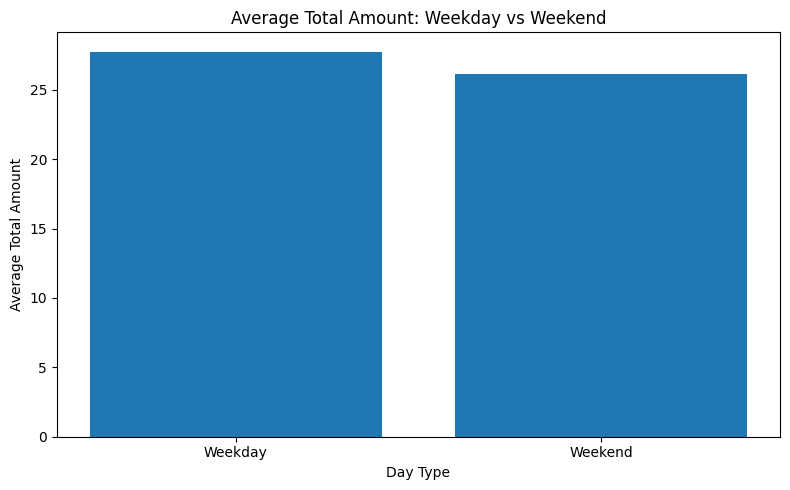

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(weekend_summary_for_plot["day_type"], weekend_summary_for_plot["average_total_amount"])
plt.title("Average Total Amount: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Total Amount")
plt.tight_layout()
plt.savefig(figures_dir / "weekday_vs_weekend_average_total_amount.png", dpi=300)
plt.show()

# 3. Pickup Borough Group Comparison

In [14]:
borough_analysis_dataset = statistical_dataset[
    statistical_dataset["pickup_borough"].notna()
    & (statistical_dataset["pickup_borough"] != "Unknown")
    & statistical_dataset["total_amount"].notna()
].copy()

borough_counts = borough_analysis_dataset["pickup_borough"].value_counts()
valid_boroughs = borough_counts[borough_counts >= 1_000].index.tolist()

borough_analysis_dataset = borough_analysis_dataset[
    borough_analysis_dataset["pickup_borough"].isin(valid_boroughs)
].copy()

# Sample to keep tests practical and balanced.
borough_sample_size = min(300_000, len(borough_analysis_dataset))
borough_analysis_sample = borough_analysis_dataset.sample(n=borough_sample_size, random_state=42)

borough_groups = [
    group["total_amount"].dropna()
    for _, group in borough_analysis_sample.groupby("pickup_borough")
]

anova_statistic, anova_p_value = stats.f_oneway(*borough_groups)
kruskal_statistic, kruskal_p_value = stats.kruskal(*borough_groups)

borough_test_results = pd.DataFrame({
    "test_name": ["One-way ANOVA", "Kruskal-Wallis"],
    "test_statistic": [anova_statistic, kruskal_statistic],
    "p_value": [anova_p_value, kruskal_p_value],
    "result": [
        interpret_p_value(anova_p_value),
        interpret_p_value(kruskal_p_value),
    ],
})

borough_test_results

,test_name,test_statistic,p_value,result
0,One-way ANOVA,"74,907.7254",0.0000,Statistically significant
1,Kruskal-Wallis,"57,513.4906",0.0000,Statistically significant


In [15]:
pickup_borough_statistical_summary = (
    borough_analysis_dataset
    .groupby("pickup_borough")
    .agg(
        total_trips=("pickup_datetime", "count"),
        average_total_amount=("total_amount", "mean"),
        median_total_amount=("total_amount", "median"),
        std_total_amount=("total_amount", "std"),
        average_trip_distance=("trip_distance", "mean"),
        average_trip_duration=("trip_duration_minutes", "mean"),
        average_revenue_per_mile=("revenue_per_mile", "mean"),
    )
    .sort_values("average_total_amount", ascending=False)
    .reset_index()
)

pickup_borough_statistical_summary

,pickup_borough,total_trips,average_total_amount,median_total_amount,std_total_amount,average_trip_distance,average_trip_duration,average_revenue_per_mile
0,Queens,257603,72.2180,72.7800,30.9251,12.8148,32.3984,19.2825
1,Bronx,5742,35.4365,34.0000,16.9389,7.7331,38.1664,15.7615
2,Brooklyn,22254,33.1919,29.0000,19.6221,14.8153,31.6431,22.6189
3,Manhattan,2572024,22.7583,19.2500,13.9834,2.7171,13.0119,17.0235
